In [30]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

IMG_SIZE = 224


In [31]:
model = load_model("ewaste_classifier.h5")
print("Model Loaded!")


Model Loaded!


In [32]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        raise ValueError("Image path is incorrect or image cannot be opened.")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    # Gaussian blur
    img_blurred = cv2.GaussianBlur(img_resized, (5, 5), 0)

    # Normalize
    img_normalized = img_blurred / 255.0

    # Expand dims → (1, 224, 224, 3)
    img_final = np.expand_dims(img_normalized, axis=0)

    return img_final, img_rgb

In [33]:
def predict_image(img_path):
    processed_img, original_img = preprocess_image(img_path)
    pred = model.predict(processed_img)[0][0]

    label = "NON E-WASTE" if pred > 0.5 else "E-WASTE"
    confidence = pred if pred > 0.5 else (1 - pred)

    # Display result
    plt.imshow(original_img)
    plt.title(f"Prediction: {label}  (Confidence: {confidence:.2f})")
    plt.axis("off")
    plt.show()

    return label, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


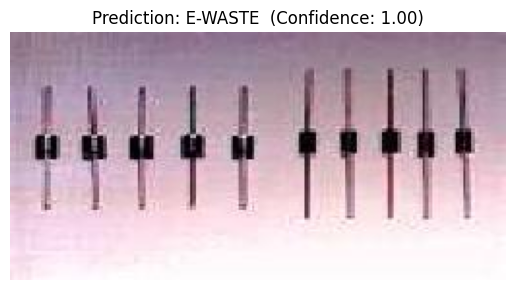

Final Prediction: E-WASTE
Confidence: 0.99527544


In [34]:
image_path = "dataset/ewaste/component_0096.jpg"
label, confidence = predict_image(image_path)

print("Final Prediction:", label)
print("Confidence:", confidence)